In [102]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *

In [103]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

ids = read_ids('filtered_ids.txt')

SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit, load_targetID=None)


In [104]:
SPECTRA = SPECTRA.SFG_filter(exclude=False)
SPECTRA = SPECTRA.subtype_filter(subtype='QSO', exclude=True)

SPECTRA.stack_data()
SPECTRA.mask_bad()

In [105]:
FIT     = FitSpectrum()
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)
print(SPECTRA.n_spectra)


59793


In [106]:
SPECTRA = FIT.label_emission_lines(SPECTRA)
# SPECTRA = FIT.significant_emission_filter(SPECTRA)
print(SPECTRA.n_spectra)

59793


In [125]:
idx = np.random.choice(SPECTRA.n_spectra, size=1, replace=False)[0]
id = SPECTRA.targetID[idx]
id = 39627818195227014
idx = SPECTRA.id2index(id)

39627818195227014
Saved ./images/39627818195227014_image.jpg


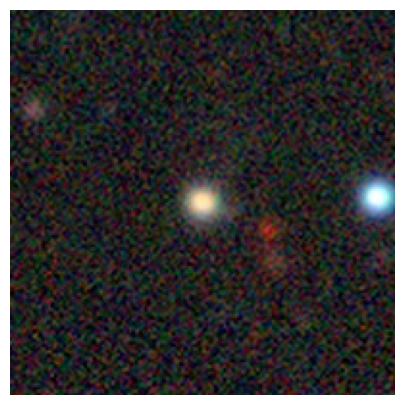

https://www.legacysurvey.org/viewer?ra=194.94632877448768&dec=1.3141742880116642&layer=ls-dr10-grz&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627818195227014


In [126]:
print(SPECTRA.targetID[idx])
print(image_link(SPECTRA.df['RA'].to_numpy()[idx], SPECTRA.df['DEC'].to_numpy()[idx], plot=True, save_image=True, fname=f"./images/{SPECTRA.targetID[idx]}_image.jpg"))
print(spectrum_link(SPECTRA.targetID[idx]))

# 1-Comp fit with dz

In [127]:
params_1comp_fixed, (combine_lam, combine_flux, combine_sigma), slice_indices = FIT.fit_multi_emission(SPECTRA, id=id, two_component=False, w_dz=True)
print(f'dz: {params_1comp_fixed["dz"]}')

lams = [
    combine_lam[:slice_indices[0]],
    combine_lam[slice_indices[0]:slice_indices[1]],
    combine_lam[slice_indices[1]:slice_indices[2]],
    combine_lam[slice_indices[2]:]
]
combine_model = np.concatenate([
                model(lams[i], gaussian_parms=params_1comp_fixed['gaussian_params'][i]) 
                for i in range(len(lams))
            ])
model_1comp_fixed = combine_model


combine_flux_1comp_fixed = combine_flux


chisq_1comp_fixed = np.sum(((combine_flux_1comp_fixed - model_1comp_fixed)/combine_sigma)**2)
# print(f'Chi-sq dz 1 comp: {chisq_dz_1comp}')


dof_1comp_fixed = len(combine_lam) - (2+8)
# 2: dz, sigma_1
# 8: amp_OII, amp_Hbeta, amp_OIII, amp_Halpha, amp_NII*2, amp_SII*2

[6.82558517e-06 2.82325583e+00 1.07512514e+01 1.16723683e+01
 9.37591773e+00 7.86308214e+00 6.00013680e+01 2.35816007e+01
 9.18501487e+00 7.48674831e+00]
dz: 6.825585170226644e-06


# 1-Comp without dz

In [128]:
params_1comp_free, (combine_lam, combine_flux, combine_sigma), slice_indices = FIT.fit_multi_emission(SPECTRA, id=id, two_component=False, w_dz=False)


lams = [
    combine_lam[:slice_indices[0]],
    combine_lam[slice_indices[0]:slice_indices[1]],
    combine_lam[slice_indices[1]:slice_indices[2]],
    combine_lam[slice_indices[2]:]
]

combine_model = np.concatenate([
                model(lams[i], gaussian_parms=params_1comp_free['gaussian_params'][i]) 
                for i in range(len(lams))
            ])
model_1comp_free = combine_model

combine_flux_1comp_free = combine_flux

chisq_1comp_free = np.sum(((combine_flux_1comp_free - model_1comp_free)/combine_sigma)**2)
# print(f'Chi-sq dz 1 comp: {chisq_dz_1comp}')


dof_1comp_free = len(combine_lam) - (1+8)
# 1: sigma_1
# 8: amp_OII, amp_Hbeta, amp_OIII, amp_Halpha, amp_NII*2, amp_SII*2

[ 2.82724246 10.74434796 11.65957109  9.36812409  7.84229086 59.9273038
 23.60564952  9.18327896  7.48857268]


# 2-Comp fit with dz, dz1, dz2

In [129]:

params_2comp_fixed, (combine_lam, combine_flux, combine_sigma), slice_indices = FIT.fit_multi_emission(SPECTRA, id=id, two_component=True, w_dz=True)
print(f'dz: {params_2comp_fixed["dz"]}')
print(f'dz1: {params_2comp_fixed["dlam"][0]}, dz2: {params_2comp_fixed["dlam"][1]}')
print(f'dz ratio (left/right): {np.abs(params_2comp_fixed["dlam"][1]/params_2comp_fixed["dlam"][0])}')

combine_flux_2comp_fixed = combine_flux
lams = [
    combine_lam[:slice_indices[0]],
    combine_lam[slice_indices[0]:slice_indices[1]],
    combine_lam[slice_indices[1]:slice_indices[2]],
    combine_lam[slice_indices[2]:]
]

combine_model = np.concatenate([
                model(lams[i], gaussian_parms=params_2comp_fixed['gaussian_params'][i]) 
                for i in range(len(lams))
            ])
model_2comp_fixed = combine_model

left_comp_dz_fixed = np.concatenate([
    model(lams[i], gaussian_parms=params_2comp_fixed['left_comp'][i]) for i in range(len(lams))
])
right_comp_dz_fixed = np.concatenate([
    model(lams[i], gaussian_parms=params_2comp_fixed['right_comp'][i]) for i in range(len(lams))
])

chisq_2comp_fixed = np.sum(((combine_flux_2comp_fixed - model_2comp_fixed)/combine_sigma)**2)
# print(f'Chi-sq dz fixed: {chisq_dz_fixed}')


dof_2comp_fixed = len(combine_lam) - (5+8*2)
# 5: dz, sigma_1, sigma_2, dz_r, dz_l
# 8*2: (amp_OII, amp_Hbeta, amp_OIII, amp_Halpha, amp_NII*2, amp_SII*2)*2 two components

[-3.05096405e-04  1.59847277e+00  1.70831475e+00  5.83881794e-04
 -2.47085898e-05  8.21361325e+00  9.52290191e+00  7.75944490e+00
  7.23015759e+00  5.64453289e+01  2.25350956e+01  7.89152334e+00
  6.45333750e+00  8.83270332e+00  8.82088298e+00  7.38878656e+00
  5.94494671e+00  4.53932033e+01  1.78767033e+01  7.83956801e+00
  6.48460014e+00]
dz: -0.0003050964050108192
dz1: 0.0005838817938055637, dz2: -2.470858980386826e-05
dz ratio (left/right): 0.04231779457075583


In [130]:
print(slice_indices)

[ 96 409 555 669]


# 2-Comp fit with dz1, dz2

In [131]:
params_2comp_free, (combine_lam, combine_flux, combine_sigma), slice_indices = FIT.fit_multi_emission(SPECTRA, id=id, two_component=True, w_dz=False)
print(f'dz: {params_2comp_free["dz"]}')

combine_flux_2comp_free = combine_flux

lams = [
    combine_lam[:slice_indices[0]],
    combine_lam[slice_indices[0]:slice_indices[1]],
    combine_lam[slice_indices[1]:slice_indices[2]],
    combine_lam[slice_indices[2]:]
]

combine_model = np.concatenate([
    model(lams[i], gaussian_parms=params_2comp_free['gaussian_params'][i]) for i in range(len(lams))
])
model_2comp_free = combine_model

left_comp_dz_free = np.concatenate([
    model(lams[i], gaussian_parms=params_2comp_free['left_comp'][i]) for i in range(len(lams))
])
right_comp_dz_free = np.concatenate([
    model(lams[i], gaussian_parms=params_2comp_free['right_comp'][i]) for i in range(len(lams))
])
model_2comp_free = left_comp_dz_free + right_comp_dz_free

chisq_2comp_free = np.sum(((combine_flux_2comp_free - model_2comp_free)/combine_sigma)**2)
# print(f'Chi-sq dz free: {chisq_dz_free}')


left_area = np.sum(left_comp_dz_free)
right_area = np.sum(right_comp_dz_free)
dz1, dz2 = params_2comp_free['dlam']
dz_centroid = (dz2*left_area + dz1*right_area)/(left_area+right_area)
print(f'dz_centroid: {dz_centroid}')

dof_2comp_free = len(combine_lam) - (4+8*2)
# 4: sigma_1, sigma_2, dz_r, dz_l
# 8*2: (amp_OII, amp_Hbeta, amp_OIII, amp_Halpha, amp_NII*2, amp_SII*2)*2 two components


[ 1.59847466e+00  1.70831014e+00  2.78784965e-04 -3.29805445e-04
  8.21361470e+00  9.52290732e+00  7.75944610e+00  7.23016688e+00
  5.64453713e+01  2.25351193e+01  7.89152870e+00  6.45333662e+00
  8.83271495e+00  8.82089488e+00  7.38879830e+00  5.94494447e+00
  4.53932113e+01  1.78766918e+01  7.83957202e+00  6.48460824e+00]
dz: 0
dz_centroid: -1.495200449265166e-05


In [132]:
print((params_2comp_free['gaussian_params'][3]))
print((params_2comp_free['left_comp'][3]))
print((params_2comp_free['right_comp'][3]))

[(np.float64(6.453336621488778), np.float64(6734.545145387542), np.float64(1.5984746636436757)), (np.float64(7.891528701752981), np.float64(6720.167272158182), np.float64(1.5984746636436757)), (np.float64(7.839572021522244), np.float64(6716.0785826703695), np.float64(1.708310138657129)), (np.float64(6.484608243568346), np.float64(6730.447708102725), np.float64(1.708310138657129))]
[(np.float64(7.839572021522244), np.float64(6716.0785826703695), np.float64(1.708310138657129)), (np.float64(6.484608243568346), np.float64(6730.447708102725), np.float64(1.708310138657129))]
[(np.float64(6.453336621488778), np.float64(6734.545145387542), np.float64(1.5984746636436757)), (np.float64(7.891528701752981), np.float64(6720.167272158182), np.float64(1.5984746636436757))]


In [133]:
F_stat = ((chisq_1comp_fixed - chisq_2comp_fixed) / (dof_1comp_fixed - dof_2comp_fixed)) / (chisq_2comp_fixed / dof_2comp_fixed)
p_value = 1 - f.cdf(F_stat, dof_1comp_fixed - dof_2comp_fixed, dof_2comp_fixed)
print(f'Fixed p_value: {p_value}')


F_stat = ((chisq_1comp_free - chisq_2comp_free) / (dof_1comp_free - dof_2comp_free)) / (chisq_2comp_free / dof_2comp_free)
p_value = 1 - f.cdf(F_stat, dof_1comp_free - dof_2comp_free, dof_2comp_free)
print(f'Free p_value: {p_value}')



# F_stat = ((chisq_2comp_free - chisq_2comp_fixed) / (dof_1comp_free - dof_2comp_fixed)) / (chisq_2comp_fixed / dof_2comp_fixed)
# p_value = 1 - f.cdf(F_stat, dof_1comp_free - dof_2comp_fixed, dof_2comp_fixed)
# print(f'2comp vs p_value (if < 0.05, w/ dz): {p_value}')

Fixed p_value: 1.1102230246251565e-16
Free p_value: 1.1102230246251565e-16


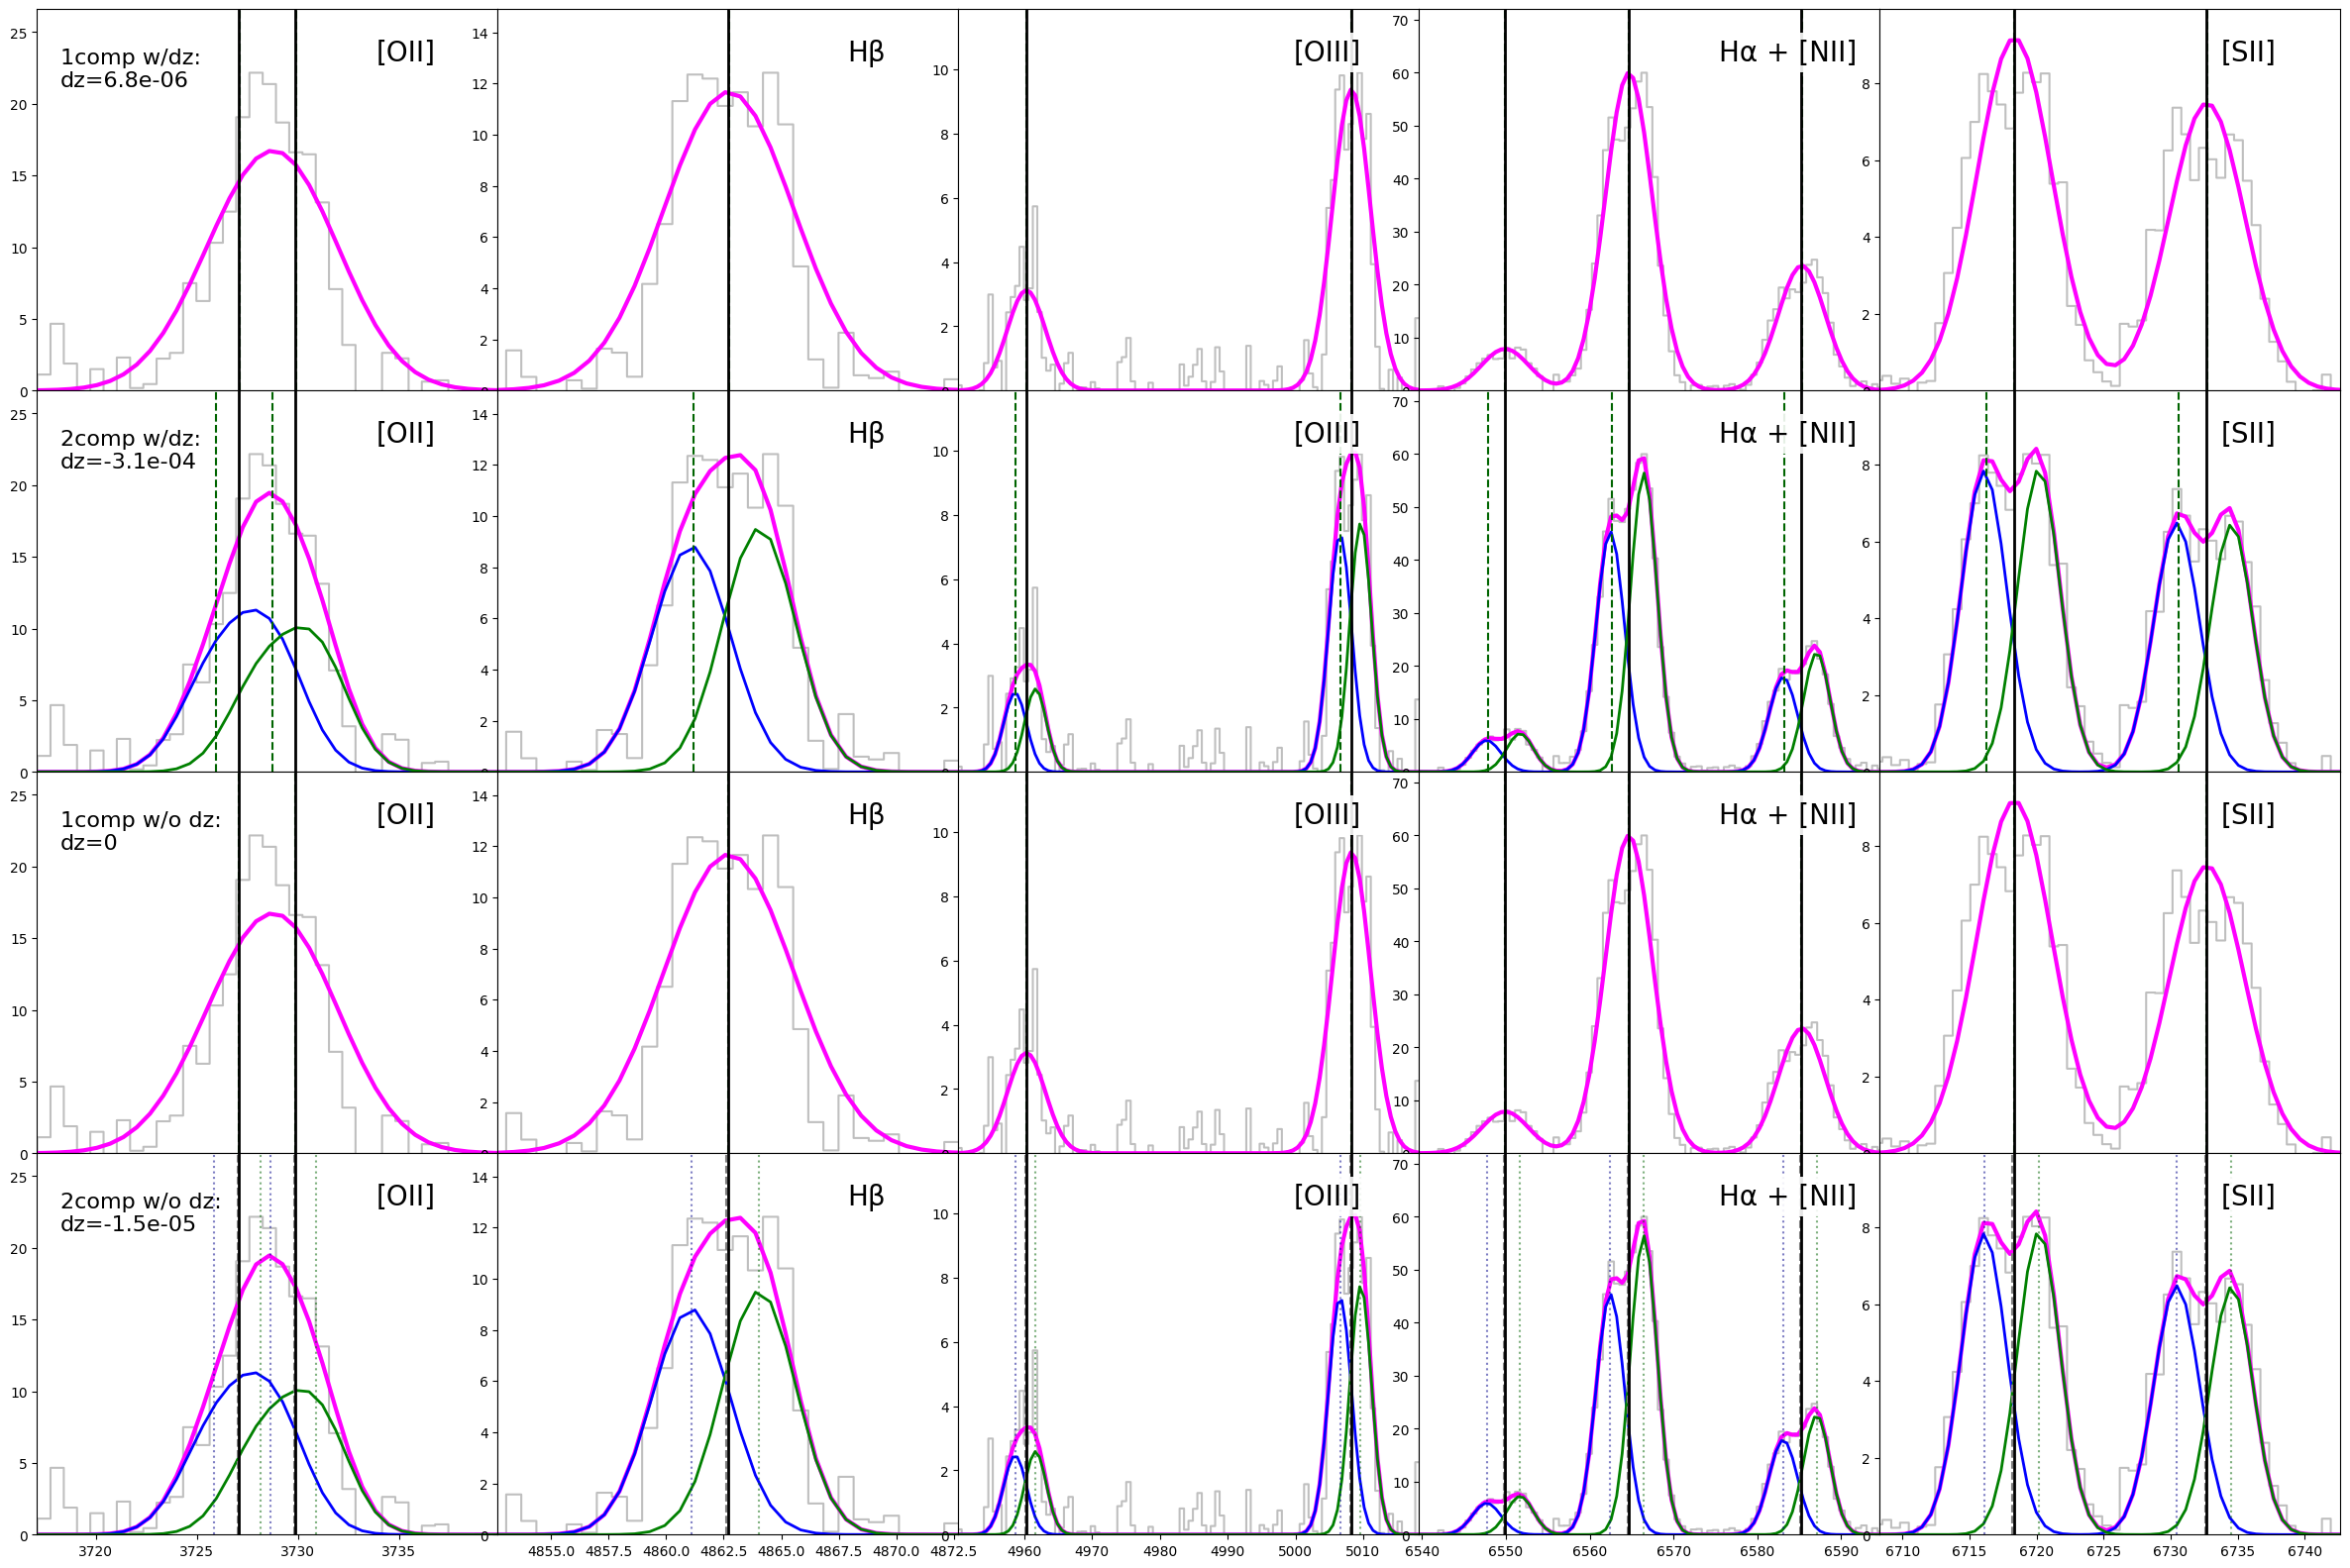

In [143]:

fig, axes = plt.subplots(4, 5, figsize=(30, 20))
plt.subplots_adjust(hspace=0.0, wspace=0.00)


# 1 comp fixed
ax = axes[0, :]
ax[0].text(0.05, 0.9, f'1comp w/dz: \ndz={params_1comp_fixed["dz"]:.1e}', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_1comp_fixed, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_1comp_fixed, label='Fitted Model', color='magenta', linewidth=3)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_1comp_fixed['dz']), color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)

# 2 comp fixed
ax = axes[1, :]
ax[0].text(0.05, 0.9, f'2comp w/dz: \ndz={params_2comp_fixed["dz"]:.1e}', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_2comp_fixed, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_2comp_fixed, label='Fitted Model', color='magenta', linewidth=3)
    ax[i].plot(combine_lam, left_comp_dz_fixed, label='Left Component', color='blue', linestyle='-', linewidth=2)
    ax[i].plot(combine_lam, right_comp_dz_fixed, label='Right Component', color='green', linestyle='-', linewidth=2)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_2comp_fixed['dz']), color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)


# 1 comp free
ax = axes[2, :]
ax[0].text(0.05, 0.9, f'1comp w/o dz: \ndz=0', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_1comp_fixed, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_1comp_fixed, label='Fitted Model', color='magenta', linewidth=3)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0, color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)


# 2 comp free
ax = axes[3, :]
ax[0].text(0.05, 0.9, f'2comp w/o dz: \ndz={dz_centroid:.1e}', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_2comp_free, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_2comp_free, label='Fitted Model', color='magenta', linewidth=3)
    ax[i].plot(combine_lam, left_comp_dz_free, label='Left Component', color='blue', linestyle='-', linewidth=2)
    ax[i].plot(combine_lam, right_comp_dz_free, label='Right Component', color='green', linestyle='-', linewidth=2)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_2comp_free['dlam'][0]), color='darkgreen', linestyle=':', alpha=.5, linewidth=1.5)
        ax[i].axvline(l0*(1+params_2comp_free['dlam'][1]), color='darkblue', linestyle=':', alpha=.5, linewidth=1.5)
        ax[i].axvline(l0*(1+dz_centroid), color='gray', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)

for i in range(4):
    ax = axes[i, :]
    ax[0].text(0.80, 0.85, '[OII]', transform=ax[0].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[0].set_xlim([OII_rest[0]-10, OII_rest[1]+10])  
    ax[0].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=OII_rest[0]-10) & (combine_lam<=OII_rest[1]+10)])*1.2)

    ax[1].text(0.80, 0.85, 'Hβ', transform=ax[1].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[1].set_xlim([Hbeta_rest[0]-10, Hbeta_rest[0]+10])
    ax[1].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=Hbeta_rest[0]-10) & (combine_lam<=Hbeta_rest[0]+10)])*1.2)

    ax[2].text(0.80, 0.85, '[OIII]', transform=ax[2].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[2].set_xlim([OIII_rest[0]-10, OIII_rest[1]+10])
    ax[2].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=OIII_rest[0]-10) & (combine_lam<=OIII_rest[1]+10)])*1.2)

    ax[3].text(0.80, 0.85, 'Hα + [NII]', transform=ax[3].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[3].set_xlim([Halpha_rest[0]-25, Halpha_rest[0]+30])
    ax[3].set_ylim(bottom=-0, top=np.max(combine_flux_2comp_free[(combine_lam>=Halpha_rest[0]-25) & (combine_lam<=Halpha_rest[0]+30)])*1.2)

    ax[4].text(0.80, 0.85, '[SII]', transform=ax[4].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[4].set_xlim([SII_rest[0]-10, SII_rest[1]+10])
    ax[4].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=SII_rest[0]-10) & (combine_lam<=SII_rest[1]+10)])*1.2)

plt.savefig(f'./figures/Dec10/{SPECTRA.targetID[idx]}_fit_comparison.png', dpi=300)
plt.show()

In [135]:
# import numpy as np
# from joblib import Parallel, delayed
# import os
# from tqdm import tqdm

# def fit_spectrum_worker(target_id):
#     """A wrapper function for the fitting process to be used by the executor."""
#     return FIT.fit_z(SPECTRA, id=target_id)

# n_jobs = 10

# results = Parallel(n_jobs=n_jobs)(delayed(fit_spectrum_worker)(i) for i in tqdm(SPECTRA.targetID))


In [136]:
# failed = []
# prefer_1comp = []
# prefer_2comp_wdz = []
# prefer_2comp_free = []

# for i, params in enumerate(results):
#     if isinstance(params, str):
#         failed.append(SPECTRA.targetID[i])
#     else:
#         if not isinstance(params['sigma'], tuple): # one comp
#             prefer_1comp.append(SPECTRA.targetID[i])
#         else:
#             if params['dz_centroid'] is None:
#                 prefer_2comp_wdz.append(SPECTRA.targetID[i])
#             else:
#                 prefer_2comp_free.append(SPECTRA.targetID[i])


In [137]:
# print(len(failed), len(prefer_1comp), len(prefer_2comp_wdz), len(prefer_2comp_free))

In [138]:
# from matplotlib.lines import Line2D

# for id in failed:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     plt.scatter(z_pipe, 1e-10, color='gray', alpha=0.3)


# for id in prefer_1comp:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz = results[SPECTRA.id2index(id)]['dz']
#     plt.scatter(z_pipe, dz, color='b', alpha=0.3)

# for id in prefer_2comp_wdz:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz = results[SPECTRA.id2index(id)]['dz']
#     plt.scatter(z_pipe, dz, color='orange', alpha=0.3)

# for id in prefer_2comp_free:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz_centroid = results[SPECTRA.id2index(id)]['dz_centroid']
#     plt.scatter(z_pipe, dz_centroid, color='r', alpha=0.3)


# plt.axhline(5e-5, color='k', linestyle='--', alpha=0.7)

# # Create custom legend handles
# legend_elements = [Line2D([0], [0], marker='o', color='w', label='Failed', markerfacecolor='k', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='1 comp', markerfacecolor='b', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='2 comp w/dz', markerfacecolor='orange', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='2 comp free', markerfacecolor='r', markersize=10, alpha=0.3)]

# plt.legend(handles=legend_elements, loc='lower left')

# plt.yscale('log')
# plt.xlabel('z')
# plt.ylabel('dz')
# plt.savefig('./figures/Nov26/dz_vs_z.png')
# plt.show()

In [139]:
# tilted_cases = []
# for id in prefer_2comp_wdz:
#     dz_r, dz_l = results[SPECTRA.id2index(id)]['dlam']
#     dz_ratio = np.abs(dz_r/dz_l)
#     if (((dz_ratio > 2.0) and (dz_ratio < 20)) or ((dz_ratio>0.05) and (dz_ratio < 0.5))) and (max(dz_r, dz_l) > 1e-7):
#         tilted_cases.append((id, dz_ratio))

In [140]:
# print(tilted_cases)

In [141]:
# high_dz_cases = []
# for id in prefer_2comp_wdz:
#     dz = results[SPECTRA.id2index(id)]['dz']
#     if (np.abs(dz) > 1e-4):
#         high_dz_cases.append((id, dz))
        



In [142]:
# sorted_high_dz = sorted(high_dz_cases, key=lambda x: np.abs(x[1]), reverse=True)
# # first 10 high dz cases
# print(sorted_high_dz[:10])